In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot

In [2]:
df = pd.read_csv("50_Startups.csv")


In [5]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
# Check data
print(df.info())
print(df.isnull().sum())
print(df.shape)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
None
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64
(50, 5)
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42   

In [4]:
# Separate features and target
X = df.iloc[:, :-1].values  # All columns except last (Profit)
y = df.iloc[:, -1].values   # Last column (Profit)

In [6]:
# Encode categorical column ("State")
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [7]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = ct.fit_transform(X)

In [8]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
# Train Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
# Predict
y_pred = regressor.predict(X_test)

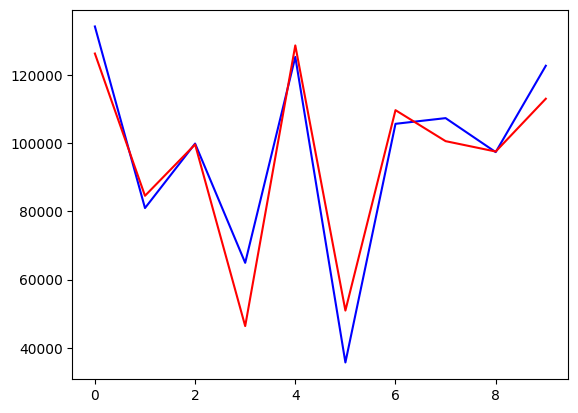

In [12]:
# Plotting of y_test vs y_pred
import matplotlib.pyplot as plt
plt.plot(y_test, color = 'blue', label = 'test')
plt.plot(y_pred, color = 'red', label = 'predictions')
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
mae = mean_absolute_error(y_pred, y_test)
print(mae)

6961.477813275558


In [15]:
mse = mean_squared_error(y_pred, y_test)
print(mse)

82010363.04501358


In [16]:
print(np.sqrt(mse))

9055.957323497807


In [17]:
r2 = r2_score(y_pred, y_test)
print(r2)

0.8851366465077517


In [18]:
# Calculate the Adjusted-R-squared

n = X_test.shape[0]
K = X_test.shape[1]

adjusted_r2 = 1-(1-r2)*(n-1)/(n-1-K)

print(adjusted_r2)

0.6554099395232551


In [19]:
print("The End")

The End
